In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Scope Corrected for Dark'] = pd.to_numeric(df['Scope Corrected for Dark'], errors='coerce')
        df.dropna(inplace=True)
        return df
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
def graficar_datos(df, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-')
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x}")
    plt.grid()
    plt.show()


def graficar_multiples_dfs(lista_dfs, nombres, columna_x, columna_y):
    
    plt.figure(figsize=(8, 5))
    for df, nombre in zip(lista_dfs, nombres):
        if df is not None and columna_x in df.columns and columna_y in df.columns:
            plt.plot(df[columna_x], df[columna_y], marker='', linestyle='-', markersize=3, linewidth=0.8, label=nombre)
        else:
            print(f"Error: No se pudo graficar {nombre}, columnas no encontradas")
    plt.xlabel(columna_x)
    plt.ylabel(columna_y)
    plt.title(f"Gráfica de {columna_y} vs {columna_x} de los 4 espectrómetros")
    plt.legend()
    plt.minorticks_on()  # Habilitar las marcas menores
    plt.grid(which='both', linestyle='-', linewidth=0.5, alpha=0.7)
    # Ajustar los márgenes de manera manual
    plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)
    plt.show()

In [ ]:
#Leer archivos

UV1 = "2.E2E_olivine/Olivine_LIBS_shot01_7324767SP.txt" 
UV2 = "2.E2E_olivine/Olivine_LIBS_shot01_7324768SP.txt" 
VIS = "2.E2E_olivine/Olivine_LIBS_shot01_7324769SP.txt" 
NIR = "2.E2E_olivine/Olivine_LIBS_shot01_7324770SP.txt" 

datos_UV1 = leer_archivo_txt(UV1)
datos_UV2 = leer_archivo_txt(UV2)
datos_VIS = leer_archivo_txt(VIS)
datos_NIR = leer_archivo_txt(NIR)


,Wave,Sample,Dark,Reference,Scope Corrected for Dark
0,691.50,158.25,0.0,0.0,158.25
1,691.70,180.25,0.0,0.0,180.25
2,691.90,119.25,0.0,0.0,119.25
3,692.10,209.25,0.0,0.0,209.25
4,692.30,123.25,0.0,0.0,123.25
...,...,...,...,...,...
2043,1055.81,311.25,0.0,0.0,311.25
2044,1055.96,315.25,0.0,0.0,315.25
2045,1056.12,311.25,0.0,0.0,311.25
2046,1056.27,314.25,0.0,0.0,314.25


In [10]:
#Declaración de los intervalos de solapamiento

wls_UV1 = datos_UV1['Wave']
wls_UV2 = datos_UV2['Wave']
wls_VIS = datos_VIS['Wave']
wls_NIR = datos_NIR['Wave']
i1 = (wls_UV2[0], wls_UV1[len(wls_UV1)-1])
i2 = (wls_VIS[0], wls_UV2[len(wls_UV2)-1])
i3 = (wls_NIR[0], wls_VIS[len(wls_VIS)-1])


In [17]:
#Aislamiento de los intervalos de solapamiento

datos_UV1_fil1 = datos_UV1[(datos_UV1['Wave'] >= i1[0]) & (datos_UV1['Wave'] <= i1[1])]
datos_UV2_fil1 = datos_UV2[(datos_UV2['Wave'] >= i1[0]) & (datos_UV2['Wave'] <= i1[1])]

datos_UV2_fil2 = datos_UV2[(datos_UV2['Wave'] >= i2[0]) & (datos_UV2['Wave'] <= i2[1])]
datos_VIS_fil2 = datos_VIS[(datos_VIS['Wave'] >= i2[0]) & (datos_VIS['Wave'] <= i2[1])]

datos_VIS_fil3 = datos_VIS[(datos_VIS['Wave'] >= i3[0]) & (datos_VIS['Wave'] <= i3[1])]
datos_NIR_fil3 = datos_NIR[(datos_NIR['Wave'] >= i3[0]) & (datos_NIR['Wave'] <= i3[1])]

In [25]:
#Extracción de las medianas

mediana_UV1_fil1 = datos_UV1_fil1['Scope Corrected for Dark'].median()
mediana_UV2_fil1 = datos_UV2_fil1['Scope Corrected for Dark'].median()

mediana_UV2_fil2 = datos_UV2_fil2['Scope Corrected for Dark'].median()
mediana_VIS_fil2 = datos_VIS_fil2['Scope Corrected for Dark'].median()

mediana_VIS_fil3 = datos_VIS_fil3['Scope Corrected for Dark'].median()
mediana_NIR_fil3 = datos_NIR_fil3['Scope Corrected for Dark'].median()


In [47]:
#Cálculo de los coeficientes

coef1 = mediana_UV1_fil1/mediana_UV2_fil1
coef2 = mediana_UV2_fil2/mediana_VIS_fil2
coef3 = mediana_VIS_fil3/mediana_NIR_fil3

coef3

np.float64(2.7443405353111903)

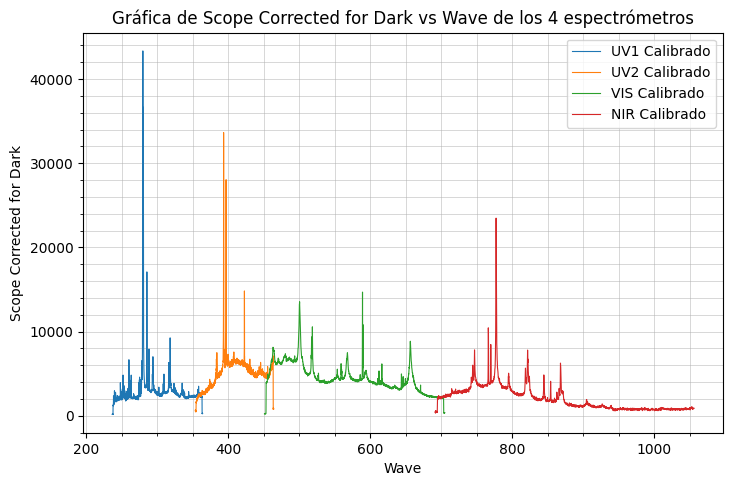

In [54]:
#Corrección del offset

datos_UV1_corr = datos_UV1.copy()
datos_UV2_corr = datos_UV2.copy()
datos_VIS_corr = datos_VIS.copy()
datos_NIR_corr = datos_NIR.copy()

datos_UV1_corr['Scope Corrected for Dark'] = datos_UV1_corr['Scope Corrected for Dark']
datos_UV2_corr['Scope Corrected for Dark'] = datos_UV2_corr['Scope Corrected for Dark']*coef1
datos_VIS_corr['Scope Corrected for Dark'] = datos_VIS_corr['Scope Corrected for Dark']*coef2*coef1
datos_NIR_corr['Scope Corrected for Dark'] = datos_NIR_corr['Scope Corrected for Dark']*coef3*coef2*coef1



dfs_calibrados = [datos_UV1_corr, datos_UV2_corr, datos_VIS_corr, datos_NIR_corr]
nombres_calibrados = ["UV1 Calibrado", "UV2 Calibrado", "VIS Calibrado", "NIR Calibrado"]
graficar_multiples_dfs(dfs_calibrados, nombres_calibrados, 'Wave', 'Scope Corrected for Dark')

